In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr

In [2]:
coloc_gdf = gpd.read_parquet("orcestra_coloc_ec_sounders_times.parquet")

In [3]:
overpass_path = Path.home() / "my-public-bucket" / "orcestra" / "overpass_sounders"
overpass_files = sorted(list(overpass_path.glob("*.nc")))

In [4]:
coloc_gdf = coloc_gdf.loc[[
    int(f.stem.split("_")[1])
    for f in overpass_files
]]

In [5]:
coloc_gdf["overpass_file"] = [str(f) for f in overpass_files]

In [6]:
coloc_gdf.columns

Index(['index_coloc', 'frame', 'idx', 'hdim_1', 'hdim_2', 'num',
       'threshold_value', 'max_precip', 'feature', 'time', 'timestr', 'lon',
       'lat', 'geometry', 'cell', 'time_cell', 'index_ec', 'granule', 'date',
       'start_time_ec', 'end_time_ec', 'enclosure_ACM_CAP_2B',
       'enclosure_AC__TC__2B', 'enclosure_ACM_RT__2B', 'enclosure_ALL_DF__2B',
       'enclosure_ATL_EBD_2A', 'enclosure_CPR_CD__2A', 'enclosure_CPR_FMR_2A',
       'index_n20', 'results_n20', 'start_time_n20', 'end_time_n20',
       'index_snpp', 'results_snpp', 'start_time_snpp', 'end_time_snpp',
       'time_diff_n20', 'time_diff_snpp', 'overpass_file', 'mean_time_ec',
       'mean_time_noaa_20', 'mean_time_snpp', 'ec_time_offset',
       'noaa_20_time_offset', 'snpp_time_offset'],
      dtype='str')

In [7]:
datatrees = [xr.open_datatree(f) for f in coloc_gdf["overpass_file"]]

In [8]:
datatrees[0]

<xarray.DataTree>
Group: /
├── Group: /AC__TC__2B
│       Dimensions:                           (along_track: 21, height: 200)
│       Coordinates:
│           time                              (along_track) datetime64[ns] 168B ...
│           latitude                          (along_track) float64 168B ...
│           longitude                         (along_track) float64 168B ...
│         * height                            (height) float64 2kB 1.995e+04 ... 50.0
│       Dimensions without coordinates: along_track
│       Data variables:
│           synergetic_target_classification  (along_track, height) float64 34kB ...
│           CPR_ATLID_status                  (along_track, height) float64 34kB ...
│           quality_status                    (along_track, height) float64 34kB ...
│       Attributes:
│           File_Name:         ECA_EXBA_AC__TC__2B_20240810T203032Z_20250904T221535Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         AC__TC__2B
│           File_Version:      0001
├── Group: /ACM_CAP_2B
│       Dimensions:                                     (along_track: 21, height: 200)
│       Coordinates:
│           time                                        (along_track) datetime64[ns] 168B ...
│           latitude                                    (along_track) float64 168B ...
│           longitude                                   (along_track) float64 168B ...
│         * height                                      (height) float64 2kB 1.995e+0...
│       Dimensions without coordinates: along_track
│       Data variables: (12/50)
│           tropopause_height                           (along_track) float32 84B ...
│           synergy_status                              (along_track) int8 21B ...
│           quality_status                              (along_track) int8 21B ...
│           ice_extinction                              (along_track, height) float32 17kB ...
│           ice_riming_index                            (along_track, height) float32 17kB ...
│           ice_riming_index_error                      (along_track, height) float32 17kB ...
│           ...                                          ...
│           aerosol_mass_content_error                  (along_track, height) float32 17kB ...
│           aerosol_extinction                          (along_track, height) float32 17kB ...
│           aerosol_extinction_error                    (along_track, height) float32 17kB ...
│           aerosol_optical_depth                       (along_track) float32 84B ...
│           aerosol_optical_depth_error                 (along_track) float32 84B ...
│           CPR_doppler_velocity                        (along_track, height) float32 17kB ...
│       Attributes:
│           File_Name:         ECA_EXBA_ACM_CAP_2B_20240810T203032Z_20250905T220717Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         ACM_CAP_2B
│           File_Version:      0001
├── Group: /ACM_RT__2B
│       Dimensions:                                      (along_track: 21,
│                                                         atmosphere_1d: 1,
│                                                         height_level: 249,
│                                                         height_layer: 248,
│                                                         atmosphere_3d: 1, height: 200)
│       Coordinates:
│           time                                         (along_track) datetime64[ns] 168B ...
│           latitude                                     (along_track) float32 84B ...
│           longitude                                    (along_track) float32 84B ...
│         * height                                       (height) float64 2kB 1.995e+...
│  

In [9]:
datatrees[0].ACM_CAP_2B.ice_water_content.where(datatrees[0].ACM_CAP_2B.quality_status<=7).mean("along_track")

<xarray.DataArray 'ice_water_content' (height: 200)> Size: 800B
array([0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 3.3729606e-07, 1.4508566e-06, 2.5245940e-06,
       2.9277085e-06, 3.4611153e-06, 4.0406912e-06, 4.6549026e-06,
       5.2043943e-06, 5.7456919e-06, 6.6817483e-06, 8.1621383e-06,
       9.9789631e-06, 1.2146905e-05, 1.3907030e-05, 1.7908225e-05,
       2.5106334e-05, 3.6146634e-05, 4.3319254e-05, 4.8763413e-05,
       5.5614277e-05, 6.3592364e-05, 7.7064557e-05, 9.9955461e-05,
       1.2971780e-04, 1.6892154e-04, 2.1420060e-04, 2.5747454e-04,
       2.9474526e-04, 3.1496322e-04, 3.1559044e-04, 3.0015068e-04,
       2.7359411e-04, 2.4241951e-04, 2.1783511e-04, 2.0541967e-04,
       2.0000221e-04, 1.9796801e-04, 2.0104177e-04, 2.0940990e-04,
       2.2325000e-04, 2.4222552e-04, 2.6203864e-04, 2.8315134e-04,
       3.0888407e-04, 3.3923195e-04, 3.7995540e-04, 4.3005304e-04,
       4.9800990e-04, 5.7545013e-04, 6.6834455e-04, 8.3356065e-04,
...
       1.5863894e-03, 1.5985650e-03, 1.6034658e-03, 1.6015063e-03,
       1.6071830e-03, 1.6075715e-03, 1.5641018e-03, 1.4914890e-03,
       1.4011069e-03, 1.3353704e-03, 1.3006716e-03, 1.2870593e-03,
       1.3102132e-03, 1.3097177e-03, 1.2923360e-03, 1.3280184e-03,
       1.3538087e-03, 1.3763191e-03, 1.4172870e-03, 1.3970468e-03,
       1.4394268e-03, 1.5986803e-03, 1.7823635e-03, 1.1054467e-03,
       1.1171494e-04, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
      dtype=float32)
Coordinates:
  * height   (height) float64 2kB 1.995e+04 1.985e+04 1.975e+04 ... 150.0 50.0

In [10]:
CPR_CD__2A_variables=[
    "doppler_velocity_best_estimate", 
    "sedimentation_velocity_best_estimate", 
    "doppler_velocity_unfolded", 
]

In [11]:
cpr_cd_profiles = [
    dt.CPR_CD__2A.to_dataset()[CPR_CD__2A_variables].where(
        dt.CPR_CD__2A.quality_status<=0
    ).mean("along_track")
    for dt in datatrees
]

In [12]:
cpr_cd_profiles_ds = xr.concat(
    cpr_cd_profiles,
    dim="overpass"
)
cpr_cd_profiles_ds.assign_coords(overpass=coloc_gdf.index)
cpr_cd_profiles_ds["time_offset"] = ("overpass", coloc_gdf.ec_time_offset)

In [13]:
cpr_cd_comp = cpr_cd_profiles_ds.groupby_bins(
    cpr_cd_profiles_ds.time_offset, pd.timedelta_range("-2h", "2h", freq="600s").to_numpy().astype("timedelta64[ns]")
).mean().assign_coords(
    time_offset_bins=(
        pd.timedelta_range("-2h", "2h", freq="600s", closed="left").to_numpy().astype("timedelta64[ns]")
        + np.timedelta64(300, "s")
    ).astype("timedelta64[s]").astype(float)
)

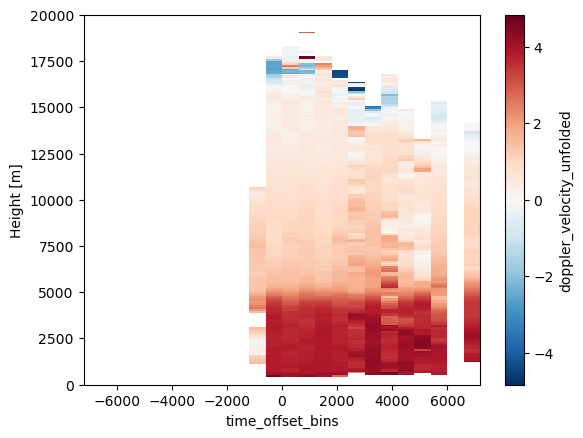

In [14]:
cpr_cd_comp.doppler_velocity_unfolded.T.plot()

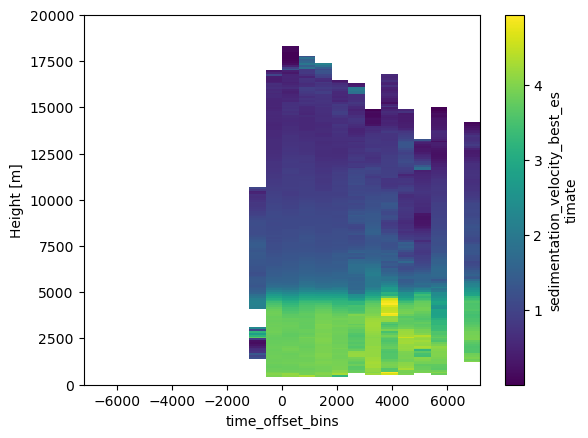

In [15]:
cpr_cd_comp.sedimentation_velocity_best_estimate.T.plot()

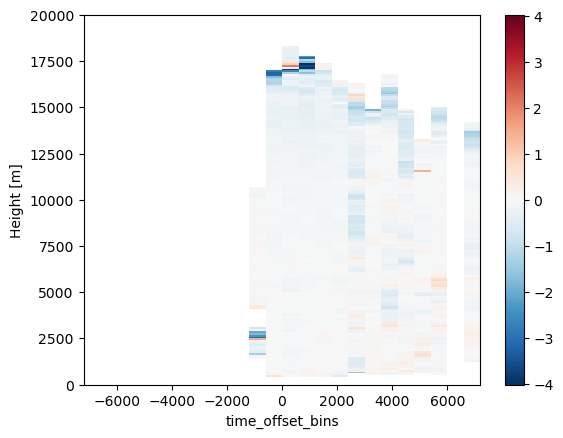

In [16]:
(
    cpr_cd_comp.doppler_velocity_best_estimate
    - cpr_cd_comp.sedimentation_velocity_best_estimate
).T.plot()

In [17]:
ACM_CAP_2B_variables=[
        "ice_water_content", 
        "ice_mass_flux", 
        "ice_effective_radius", 
        "rain_rate", 
        "rain_water_content", 
        "rain_median_volume_diameter", 
        "liquid_water_content", 
        "liquid_effective_radius", 
        "CPR_doppler_velocity", 
    ]

In [18]:
datatrees[0].ACM_CAP_2B.to_dataset()[ACM_CAP_2B_variables].where(
    datatrees[0].ACM_CAP_2B.quality_status<=7
).mean("along_track")

<xarray.Dataset> Size: 9kB
Dimensions:                      (height: 200)
Coordinates:
  * height                       (height) float64 2kB 1.995e+04 ... 50.0
Data variables:
    ice_water_content            (height) float32 800B 0.0 0.0 0.0 ... 0.0 0.0
    ice_mass_flux                (height) float32 800B 0.0 0.0 0.0 ... 0.0 0.0
    ice_effective_radius         (height) float32 800B nan nan nan ... nan nan
    rain_rate                    (height) float32 800B 0.0 0.0 0.0 ... 0.0 0.0
    rain_water_content           (height) float32 800B 0.0 0.0 0.0 ... 0.0 0.0
    rain_median_volume_diameter  (height) float32 800B nan nan nan ... nan nan
    liquid_water_content         (height) float32 800B 0.0 0.0 0.0 ... 0.0 0.0
    liquid_effective_radius      (height) float32 800B nan nan nan ... nan nan
    CPR_doppler_velocity         (height) float32 800B nan nan nan ... nan nan

In [19]:
acm_cap_profiles = [
    dt.ACM_CAP_2B.to_dataset()[ACM_CAP_2B_variables].where(
        dt.ACM_CAP_2B.quality_status<=7
    ).mean("along_track")
    for dt in datatrees
]

In [20]:
acm_cap_profiles_ds = xr.concat(
    acm_cap_profiles,
    dim="overpass"
)

In [21]:
acm_cap_profiles_ds.assign_coords(overpass=coloc_gdf.index)
acm_cap_profiles_ds["time_offset"] = ("overpass", coloc_gdf.ec_time_offset)

In [22]:
pd.timedelta_range("-2h", "2h", freq="600s").to_numpy().astype("timedelta64[ns]")

array([-7200000000000, -6600000000000, -6000000000000, -5400000000000,
       -4800000000000, -4200000000000, -3600000000000, -3000000000000,
       -2400000000000, -1800000000000, -1200000000000,  -600000000000,
                    0,   600000000000,  1200000000000,  1800000000000,
        2400000000000,  3000000000000,  3600000000000,  4200000000000,
        4800000000000,  5400000000000,  6000000000000,  6600000000000,
        7200000000000], dtype='timedelta64[ns]')

In [23]:
acm_cap_profiles_ds.time_offset

<xarray.DataArray 'time_offset' (overpass: 958)> Size: 8kB
array([  572527589577,   954413262774,   972055949200,   869029914484,
        1346768174555,  -445969249474,  1188553844666,  1185491298061,
        1771842311964,  1095097064037,  1892268590165,    91414809878,
         207338289030,   711199780617,   539209376587,   836127149653,
        1851663930308,    51163924760,   912409039695,  1992521478649,
         193582035708,  2296451638931,   769671472260,   496593812105,
         828190261594,   954831911608,  1762908361792,  2238706533422,
         -36636072306,   167475966126,  1718159255542,   -81971054316,
        1836729903059,  1775128367930,   -22757574300,  7437305298573,
        2348668070182,   547512227376,   548226741955,  1237837794048,
        -563033060208,  -564742904617,  1257262542016,  -453323463724,
        -307025361430,  -100453863689,  1612113940381,  1698440673472,
        1669938872438,  -129161796236,  -130329153303,  -130710021089,
         678396700224,   618158582833,   415726329088,   183777308815,
        1506188842261,  2048635782212,   247915563061,   247712782912,
        1548369406446,   587183044978,   140796370076,   871398157783,
          65079677491,  1165102936171,  1952052922946,  -209249113862,
        1622395204156,  1845393877693,  1154975514098,  -275258586069,
         781675189072,   780102914522,   777059385974,   770279639356,
        1065814294144,  1666884652220,    90456756672,  1575145222002,
...
          62752245573,   534964693708,   772894260384,  -232719512567,
         -49723193137,    94998396486,   457453982483,  1344993605585,
        1350577735942,    74400501308,  1550179039355,   925303054384,
         903339774261,  1697631981585,   463196856281,  1240981541060,
         286166425677,  1440479229742,  1239702224564,   490580576648,
        1672300216224,   352278044970,  1895150535794,    94664971207,
          90409925394,  -146943309707,  1982393459968,  1982393459968,
         182329305888,  1707008587282,  1684978309901,  1682949205406,
        1672723215283,  1668038041890,  -135717867569,  -133444290918,
        -135950505896,  1090049036172,  1791719559234,  3205262937063,
        1749545756160,  1749545756160,  1879008258874,    79315208207,
        2920538961472,  1117606593294,  1630264765680,  -170086857635,
        1418144482181,  -382326641466,  -390618449351,   801952281293,
         733881328576,  -146193405142,  1200411227882,  1200411227882,
        1186881120585,  2322023879475,  2322023879475,   522001585271,
         745892838381,  1314084416856,  3233022787921,  -356895612193,
        3239706095710,  1804803419988,     5178424742,   103663807168,
        1255502896684,  1243907070107,  1713929861241,   414452345521,
         -85864313277,  1793135748884,  1793135748884,  1007577561258,
        -201545992691,  -422627290105], dtype='timedelta64[ns]')
Dimensions without coordinates: overpass

In [24]:
acm_cap_comp = acm_cap_profiles_ds.groupby_bins(
    acm_cap_profiles_ds.time_offset, pd.timedelta_range("-2h", "2h", freq="900s").to_numpy().astype("timedelta64[ns]")
).mean().assign_coords(
    time_offset_bins=(
        pd.timedelta_range("-2h", "2h", freq="900s", closed="left").to_numpy().astype("timedelta64[ns]")
        + np.timedelta64(450, "s")
    ).astype("timedelta64[s]").astype(float)
)

In [25]:
acm_cap_comp.ice_water_content

<xarray.DataArray 'ice_water_content' (time_offset_bins: 16, height: 200)> Size: 13kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]],
      shape=(16, 200), dtype=float32)
Coordinates:
  * height            (height) float64 2kB 1.995e+04 1.985e+04 ... 150.0 50.0
  * time_offset_bins  (time_offset_bins) float64 128B -6.75e+03 ... 6.75e+03

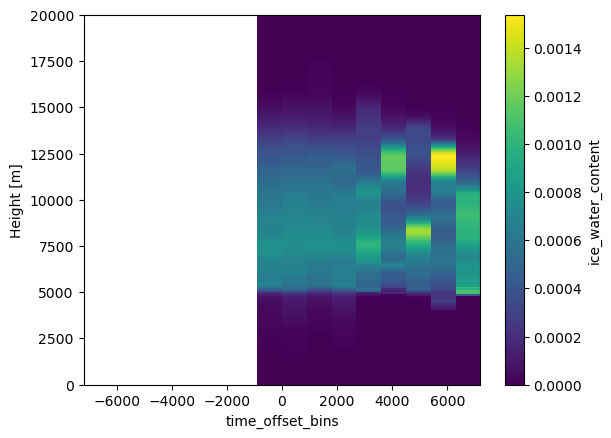

In [26]:
acm_cap_comp.ice_water_content.T.plot()

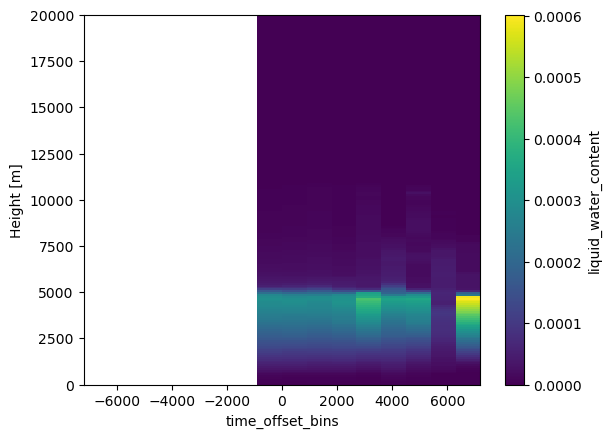

In [27]:
acm_cap_comp.liquid_water_content.T.plot()

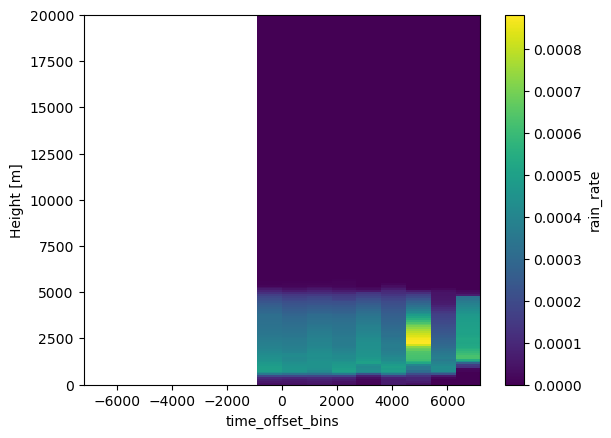

In [28]:
acm_cap_comp.rain_rate.T.plot()

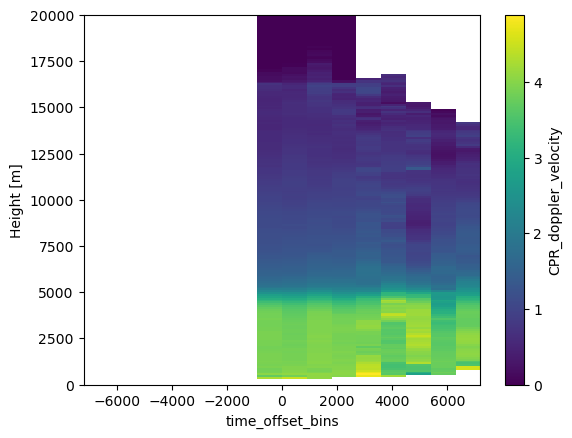

In [29]:
acm_cap_comp.CPR_doppler_velocity.T.plot()

In [30]:
datatrees[0].noaa_20.CAPE.where(datatrees[0].noaa_20.CAPE_CIN_qc<=1).mean()

<xarray.DataArray 'CAPE' ()> Size: 8B
array(288.42443097)

In [31]:
datatrees[0].noaa_20.CIN.where(datatrees[0].noaa_20.CAPE_CIN_qc<=1).mean()

<xarray.DataArray 'CIN' ()> Size: 8B
array(-17.86856951)

In [32]:
dt = datatrees[0]

In [33]:
dt.noaa_20

<xarray.DataTree 'noaa_20'>
Group: /noaa_20
    Dimensions:            (atrack: 15, xtrack: 10, height: 200)
    Coordinates:
        lat                (atrack, xtrack) float32 600B ...
        lon                (atrack, xtrack) float32 600B ...
        subsat_lat         (atrack) float32 60B ...
        subsat_lon         (atrack) float32 60B ...
      * height             (height) float64 2kB 50.0 150.0 ... 1.985e+04 1.995e+04
        obs_time_tai93     (atrack, xtrack) datetime64[ns] 1kB ...
    Dimensions without coordinates: atrack, xtrack
    Data variables: (12/47)
        air_temp           (atrack, xtrack, height) float32 120kB ...
        air_temp_qc        (atrack, xtrack, height) float32 120kB ...
        air_temp_err       (atrack, xtrack, height) float32 120kB ...
        surf_air_temp      (atrack, xtrack) float32 600B ...
        surf_air_temp_qc   (atrack, xtrack) float32 600B ...
        surf_air_temp_err  (atrack, xtrack) float32 600B ...
        ...                 ...
        tpause_temp_qc     (atrack, xtrack) float32 600B ...
        CAPE               (atrack, xtrack) float64 1kB ...
        CIN                (atrack, xtrack) float64 1kB ...
        CAPE_CIN_qc        (atrack, xtrack) float32 600B nan nan 2.0 ... 0.0 nan nan
        k_index            (atrack, xtrack) float64 1kB ...
        k_index_qc         (atrack, xtrack) float32 600B ...
    Attributes: (12/82)
        geospatial_bounds:                 POLYGON ((86.04 14.29, 62.86 17.77, 58...
        product_name_version:              v03_21
        product_name_extension:            nc
        geospatial_lon_min:                58.613804
        creator_institution:               Goddard Space Flight Center - National...
        id:                                10.5067/69Y2R9BJAJS3
        ...                                ...
        AutomaticQualityFlag:              Passed
        instrument_vocabulary:             GCMD:GCMD Keywords
        date_created:                      2024-09-24T20:18:07.000Z
        license:                           Freely Distributed
        algorithm_version:                 V3.0.0,(20-Jan-2022)firo:1.0(30-JAN-2019)
        cdm_data_type:                     Swath

In [34]:
sounder_vars = [
    "air_temp", 
    "surf_air_temp", 
    "rel_hum", 
    "surf_rel_hum", 
    "spec_hum", 
    "surf_spec_hum", 
    "tpause_gp_hgt", 
    "CAPE", 
    "CIN", 
]

In [35]:
ds = dt.noaa_20.to_dataset()

In [36]:
xr.merge(
    [
        ds[var].where(ds.CAPE_CIN_qc<=1).mean(
            ["atrack", "xtrack"]
        ) if var in ["CAPE", "CIN"] 
        else ds[var].where(ds[f'{var}_qc']<=1).mean(
            ["atrack", "xtrack"]
        )
        for var in sounder_vars
    ]
)

<xarray.Dataset> Size: 4kB
Dimensions:        (height: 200)
Coordinates:
  * height         (height) float64 2kB 50.0 150.0 250.0 ... 1.985e+04 1.995e+04
Data variables:
    air_temp       (height) float32 800B 303.2 300.1 298.5 ... 206.6 206.7 206.8
    surf_air_temp  float32 4B 296.9
    rel_hum        (height) float32 800B 0.7169 0.7933 0.8301 ... nan nan nan
    surf_rel_hum   float32 4B 0.856
    spec_hum       (height) float32 800B 0.01973 0.01833 0.01759 ... nan nan nan
    surf_spec_hum  float32 4B 0.01668
    tpause_gp_hgt  float32 4B 1.52e+04
    CAPE           float64 8B 288.4
    CIN            float64 8B -17.87

In [37]:
def get_sounder_mean_profile(ds):
    return xr.merge(
        [
            ds[var].where(ds.CAPE_CIN_qc<=1).mean(
                ["atrack", "xtrack"]
            ) if var in ["CAPE", "CIN"] 
            else ds[var].where(ds[f'{var}_qc']<=1).mean(
                ["atrack", "xtrack"]
            )
            for var in sounder_vars
        ]
    )


In [38]:
noaa_20_profiles = [
    get_sounder_mean_profile(dt.noaa_20.to_dataset())
    for dt in datatrees
]

snpp_profiles = [
    get_sounder_mean_profile(dt.snpp.to_dataset())
    for dt in datatrees
]

In [39]:
sounder_profiles_ds = xr.concat(
    [
        xr.concat(noaa_20_profiles, dim="overpass").assign(time_offset = ("overpass", coloc_gdf.noaa_20_time_offset)), 
        xr.concat(snpp_profiles, dim="overpass").assign(time_offset = ("overpass", coloc_gdf.snpp_time_offset)), 
    ], 
    dim="overpass"
)

In [40]:
sounder_comp = sounder_profiles_ds.groupby_bins(
    sounder_profiles_ds.time_offset, pd.timedelta_range("-2h", "2h", freq="900s").to_numpy().astype("timedelta64[ns]")
).mean().assign_coords(
    time_offset_bins=(
        pd.timedelta_range("-2h", "2h", freq="900s", closed="left").to_numpy().astype("timedelta64[ns]")
        + np.timedelta64(450, "s")
    ).astype("timedelta64[s]").astype(float)
)

In [41]:
sounder_comp

<xarray.Dataset> Size: 41kB
Dimensions:           (height: 200, time_offset_bins: 16)
Coordinates:
  * height            (height) float64 2kB 50.0 150.0 ... 1.985e+04 1.995e+04
  * time_offset_bins  (time_offset_bins) float64 128B -6.75e+03 ... 6.75e+03
Data variables:
    air_temp          (time_offset_bins, height) float32 13kB 288.8 ... 208.1
    surf_air_temp     (time_offset_bins) float32 64B 288.5 296.4 ... nan 290.2
    rel_hum           (time_offset_bins, height) float32 13kB 0.8806 ... nan
    surf_rel_hum      (time_offset_bins) float32 64B 0.8366 0.8098 ... nan 0.883
    spec_hum          (time_offset_bins, height) float32 13kB 0.01066 ... nan
    surf_spec_hum     (time_offset_bins) float32 64B 0.01067 0.01571 ... 0.01263
    tpause_gp_hgt     (time_offset_bins) float32 64B 1.264e+04 ... 1.503e+04
    CAPE              (time_offset_bins) float64 128B 303.8 455.4 ... nan 28.3
    CIN               (time_offset_bins) float64 128B -3.582 -9.588 ... -16.83
    time_offset       (time_offset_bins) timedelta64[ns] 128B -1 days +22:08:...

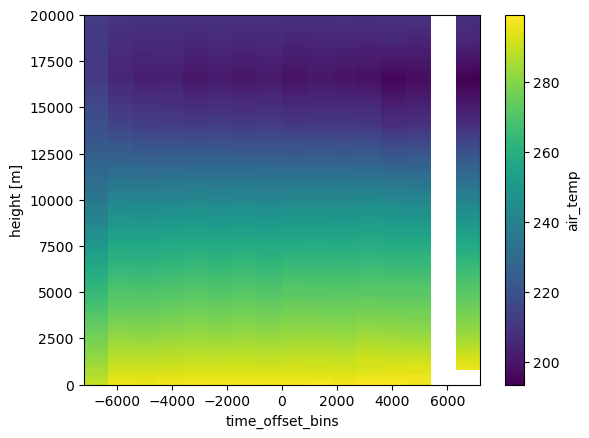

In [42]:
sounder_comp.air_temp.T.plot()

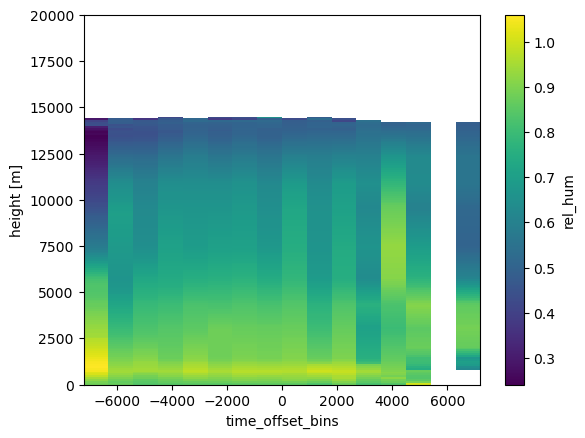

In [43]:
sounder_comp.rel_hum.T.plot()

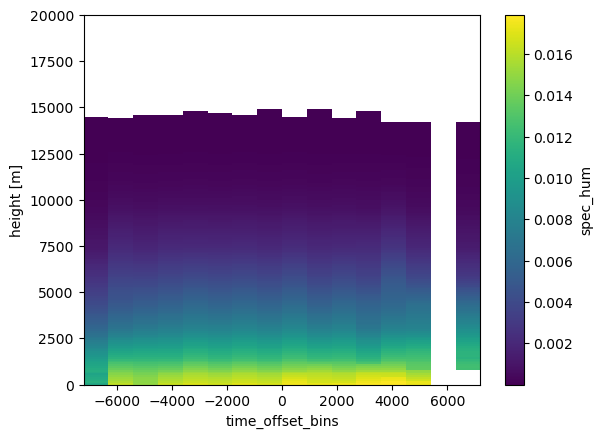

In [44]:
sounder_comp.spec_hum.T.plot()

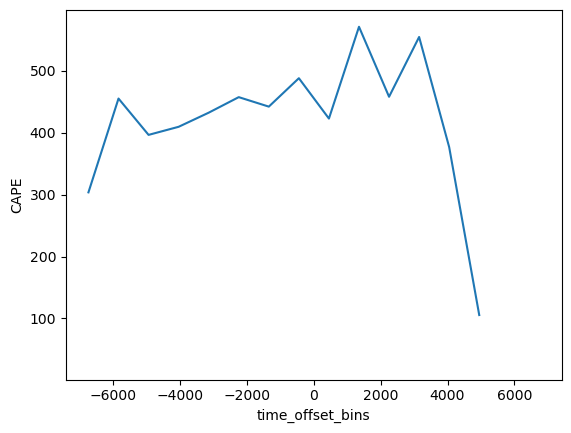

In [45]:
sounder_comp.CAPE.plot()

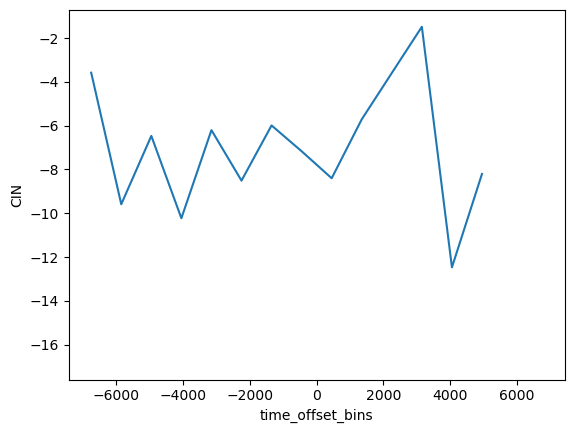

In [46]:
sounder_comp.CIN.plot()

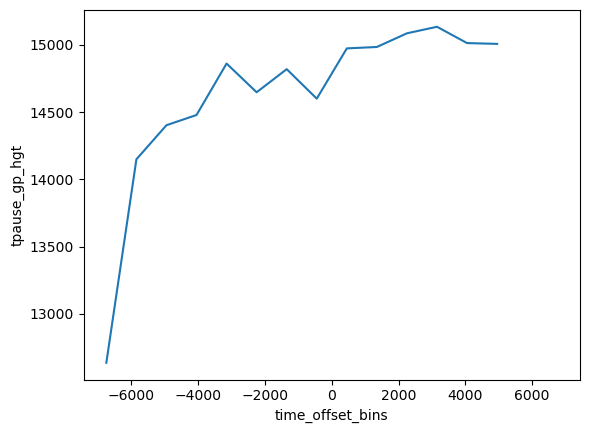

In [47]:
sounder_comp.tpause_gp_hgt.plot()

In [71]:
import matplotlib.pyplot as plt

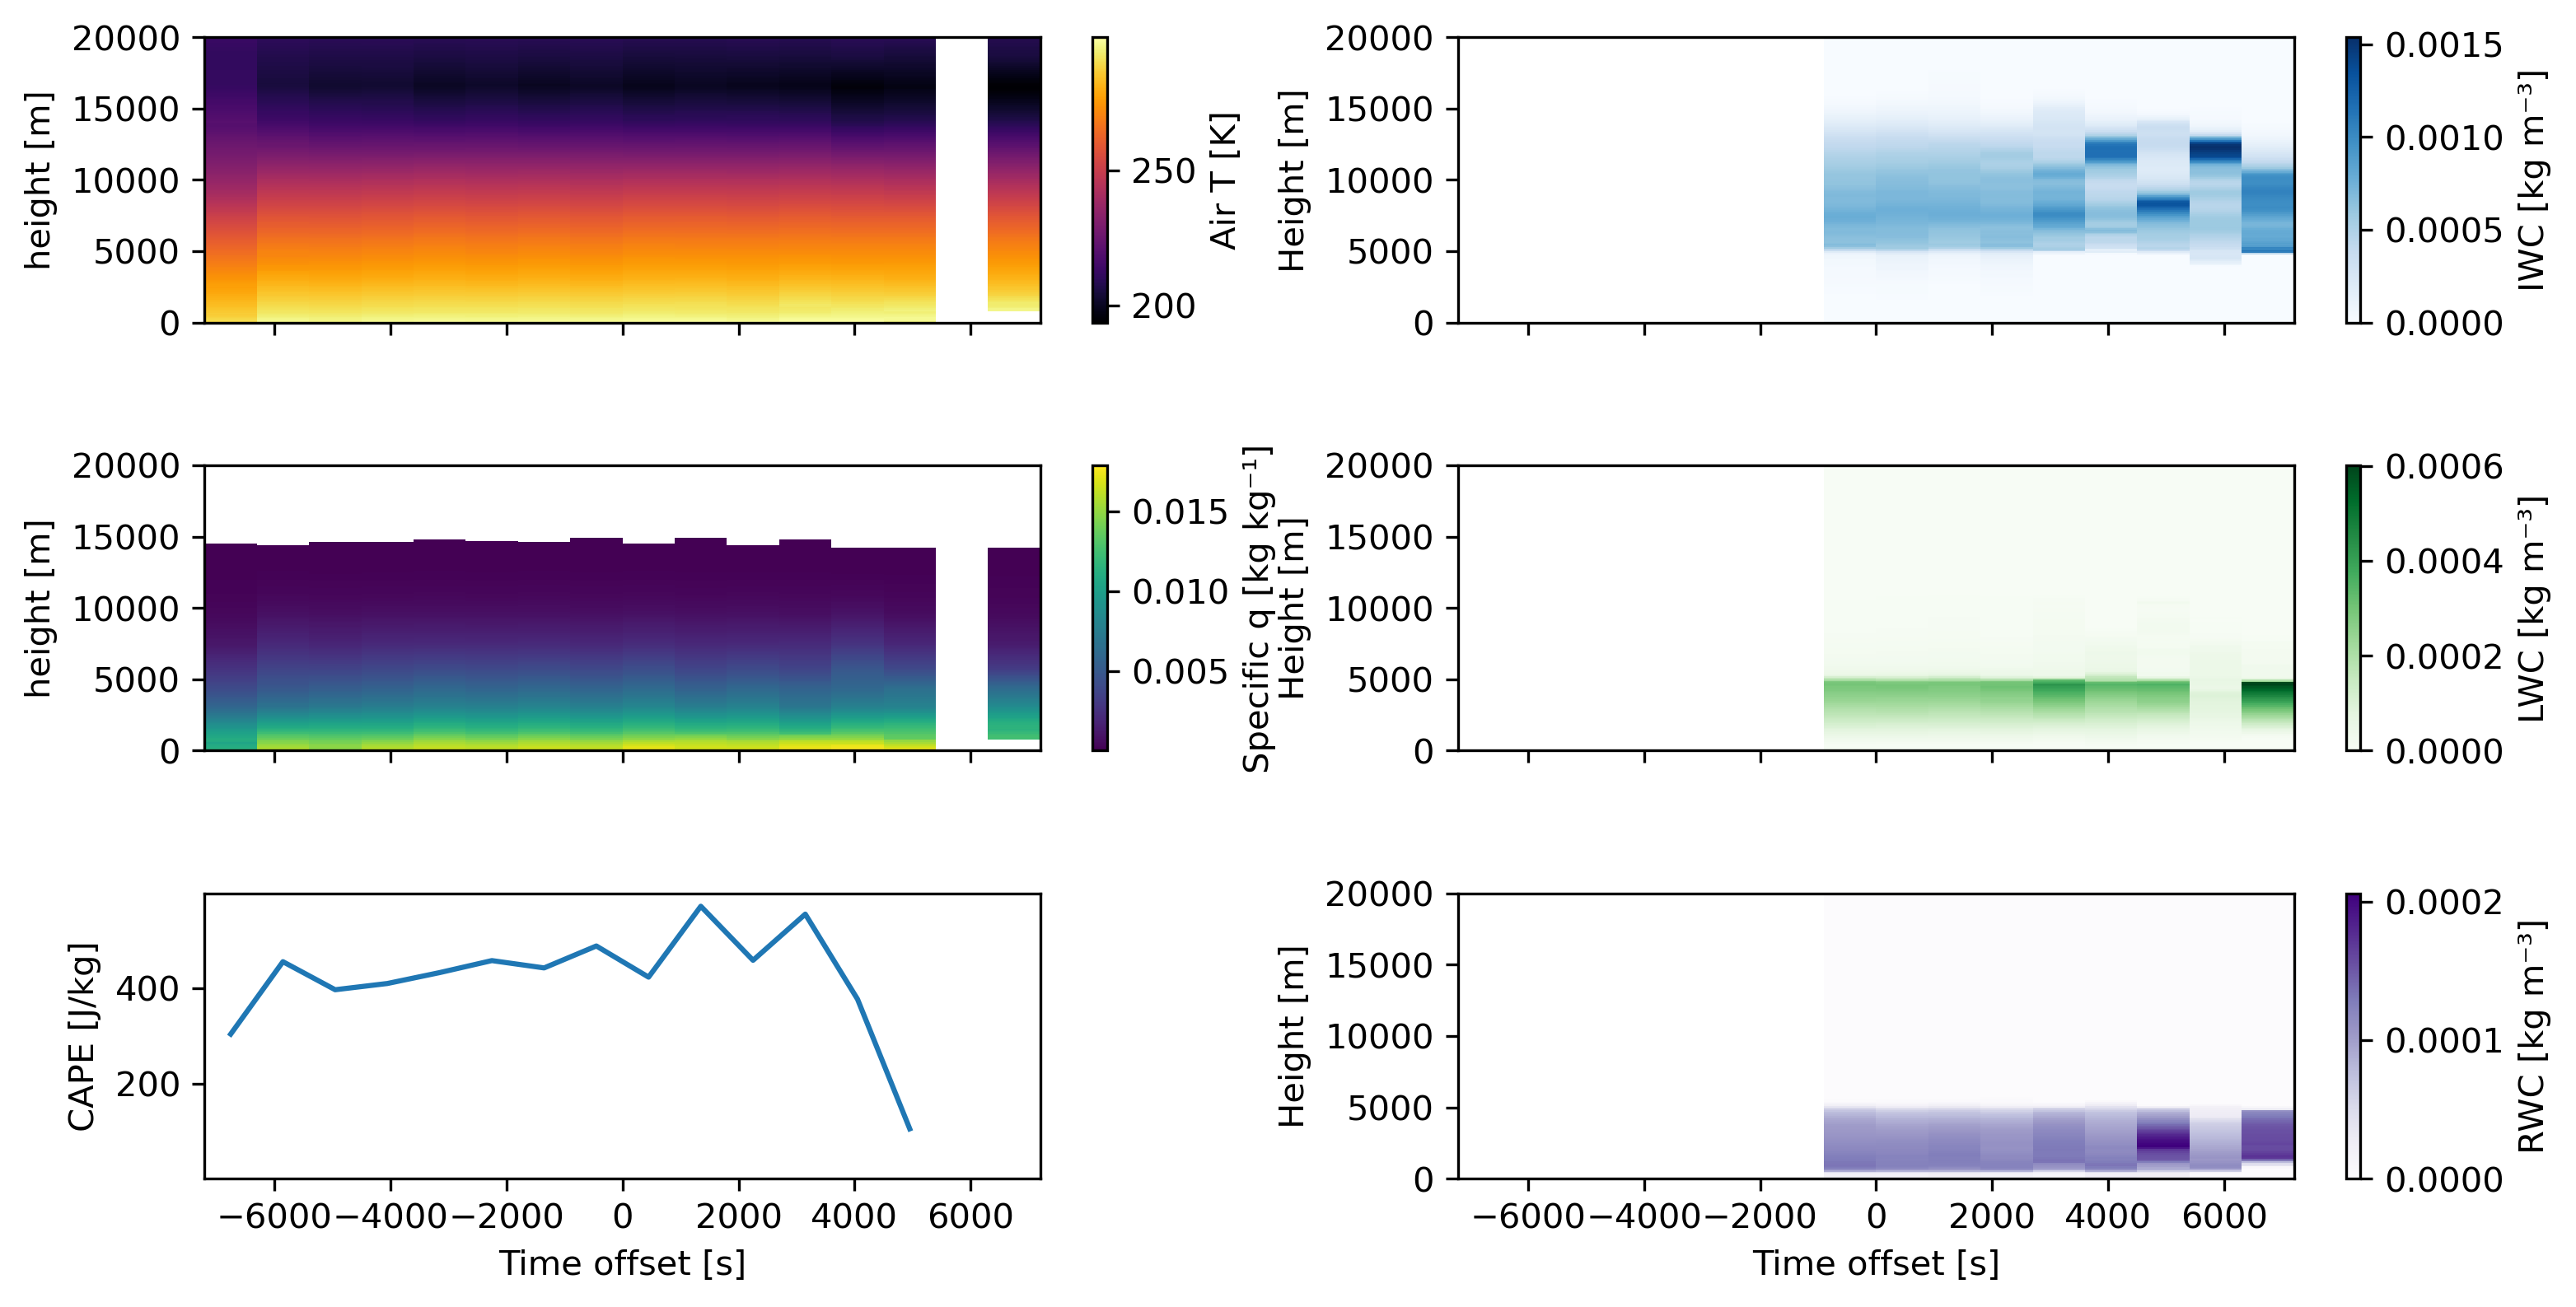

In [98]:
fig, axes = plt.subplots(3,2,dpi=300, sharex=True, figsize=(12,6))

sounder_comp.air_temp.T.plot(ax=axes[0,0], cbar_kwargs={"label":"Air T [K]"}, cmap="inferno")
sounder_comp.spec_hum.T.plot(ax=axes[1,0], cbar_kwargs={"label":"Specific q [kg kg⁻¹]"})
sounder_comp.CAPE.plot(ax=axes[2,0])
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
ax1_divider = make_axes_locatable(axes[2,0])
cax1 = ax1_divider.append_axes("right", "5%")
cax1.set_axis_off()
axes[2,0].set_ylabel("CAPE [J/kg]")
axes[0,0].set_xlabel("")
axes[1,0].set_xlabel("")
axes[2,0].set_xlabel("Time offset [s]")

acm_cap_comp.ice_water_content.T.plot(ax=axes[0,1], cbar_kwargs={"label":"IWC [kg m⁻³]"}, cmap="Blues")
acm_cap_comp.liquid_water_content.T.plot(ax=axes[1,1], cbar_kwargs={"label":"LWC [kg m⁻³]"}, cmap="Greens")
acm_cap_comp.rain_water_content.T.plot(ax=axes[2,1], cbar_kwargs={"label":"RWC [kg m⁻³]"}, cmap="Purples")
axes[0,1].set_xlabel("")
axes[1,1].set_xlabel("")
axes[2,1].set_xlabel("Time offset [s]")
plt.subplots_adjust(hspace=0.5)

In [48]:
np.percentile(sounder_profiles_ds.CAPE, [0.5])

array([nan])

In [51]:
np.max(sounder_profiles_ds.CAPE)

<xarray.DataArray 'CAPE' ()> Size: 8B
array(4246.37434362)

In [55]:
np.isnan(sounder_profiles_ds.CAPE)

<xarray.DataArray 'CAPE' (overpass: 1916)> Size: 2kB
array([False, False, False, ..., False, False, False], shape=(1916,))
Dimensions without coordinates: overpass

In [56]:
1916/2

958.0

In [57]:
np.percentile(sounder_profiles_ds.CAPE[:958][np.isfinite(sounder_profiles_ds.CAPE[:958])], [50])

array([329.79534477])

In [59]:
wh_upper_percentile = sounder_profiles_ds.CAPE[:958] > 330
wh_lower_percentile = sounder_profiles_ds.CAPE[:958] < 330

In [62]:
wh_upper_percentile.shape

(958,)

In [63]:
acm_cap_profiles_ds.overpass.shape

(958,)

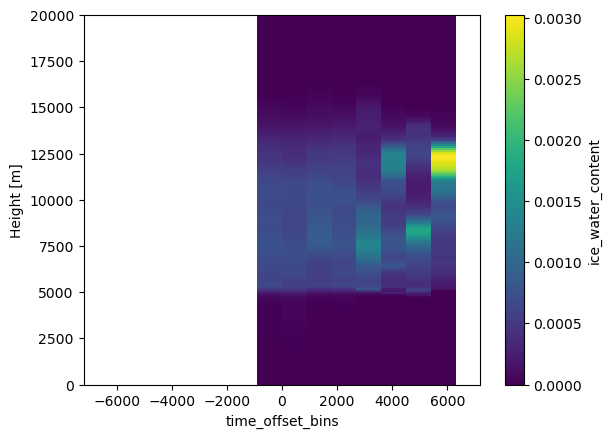

In [65]:
acm_cap_profiles_ds.isel(overpass=wh_upper_percentile.values).groupby_bins(
    acm_cap_profiles_ds.time_offset[wh_upper_percentile.values], pd.timedelta_range("-2h", "2h", freq="900s").to_numpy().astype("timedelta64[ns]")
).mean().assign_coords(
    time_offset_bins=(
        pd.timedelta_range("-2h", "2h", freq="900s", closed="left").to_numpy().astype("timedelta64[ns]")
        + np.timedelta64(450, "s")
    ).astype("timedelta64[s]").astype(float)
).ice_water_content.T.plot()

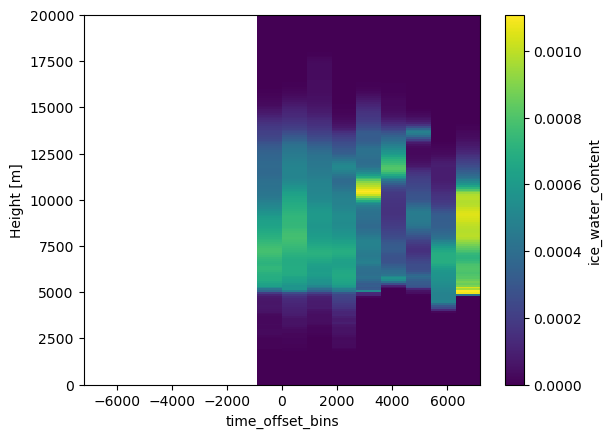

In [66]:
acm_cap_profiles_ds.isel(overpass=wh_lower_percentile.values).groupby_bins(
    acm_cap_profiles_ds.time_offset[wh_lower_percentile.values], pd.timedelta_range("-2h", "2h", freq="900s").to_numpy().astype("timedelta64[ns]")
).mean().assign_coords(
    time_offset_bins=(
        pd.timedelta_range("-2h", "2h", freq="900s", closed="left").to_numpy().astype("timedelta64[ns]")
        + np.timedelta64(450, "s")
    ).astype("timedelta64[s]").astype(float)
).ice_water_content.T.plot()

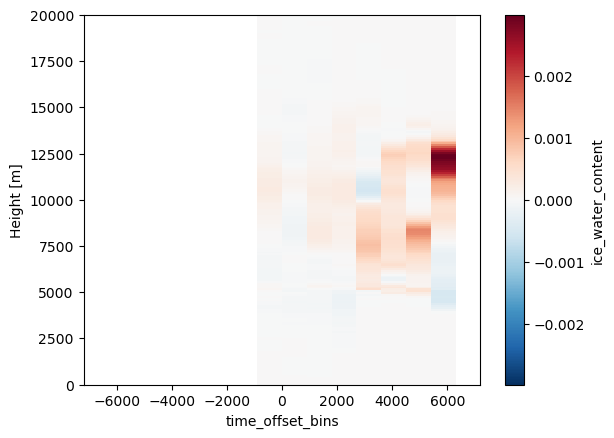

In [67]:
(
    acm_cap_profiles_ds.isel(overpass=wh_upper_percentile.values).groupby_bins(
        acm_cap_profiles_ds.time_offset[wh_upper_percentile.values], pd.timedelta_range("-2h", "2h", freq="900s").to_numpy().astype("timedelta64[ns]")
    ).mean().assign_coords(
        time_offset_bins=(
            pd.timedelta_range("-2h", "2h", freq="900s", closed="left").to_numpy().astype("timedelta64[ns]")
            + np.timedelta64(450, "s")
        ).astype("timedelta64[s]").astype(float)
    ).ice_water_content \
    - acm_cap_profiles_ds.isel(overpass=wh_lower_percentile.values).groupby_bins(
        acm_cap_profiles_ds.time_offset[wh_lower_percentile.values], pd.timedelta_range("-2h", "2h", freq="900s").to_numpy().astype("timedelta64[ns]")
    ).mean().assign_coords(
        time_offset_bins=(
            pd.timedelta_range("-2h", "2h", freq="900s", closed="left").to_numpy().astype("timedelta64[ns]")
            + np.timedelta64(450, "s")
        ).astype("timedelta64[s]").astype(float)
    ).ice_water_content
).T.plot()

In [101]:
acm_cap_comp_high = acm_cap_profiles_ds.isel(overpass=wh_upper_percentile.values).groupby_bins(
        acm_cap_profiles_ds.time_offset[wh_upper_percentile.values], pd.timedelta_range("-2h", "2h", freq="900s").to_numpy().astype("timedelta64[ns]")
    ).mean().assign_coords(
        time_offset_bins=(
            pd.timedelta_range("-2h", "2h", freq="900s", closed="left").to_numpy().astype("timedelta64[ns]")
            + np.timedelta64(450, "s")
        ).astype("timedelta64[s]").astype(float)
    )

acm_cap_comp_low = acm_cap_profiles_ds.isel(overpass=wh_lower_percentile.values).groupby_bins(
        acm_cap_profiles_ds.time_offset[wh_lower_percentile.values], pd.timedelta_range("-2h", "2h", freq="900s").to_numpy().astype("timedelta64[ns]")
    ).mean().assign_coords(
        time_offset_bins=(
            pd.timedelta_range("-2h", "2h", freq="900s", closed="left").to_numpy().astype("timedelta64[ns]")
            + np.timedelta64(450, "s")
        ).astype("timedelta64[s]").astype(float)
    )

Text(0.5, 1.0, 'Difference')

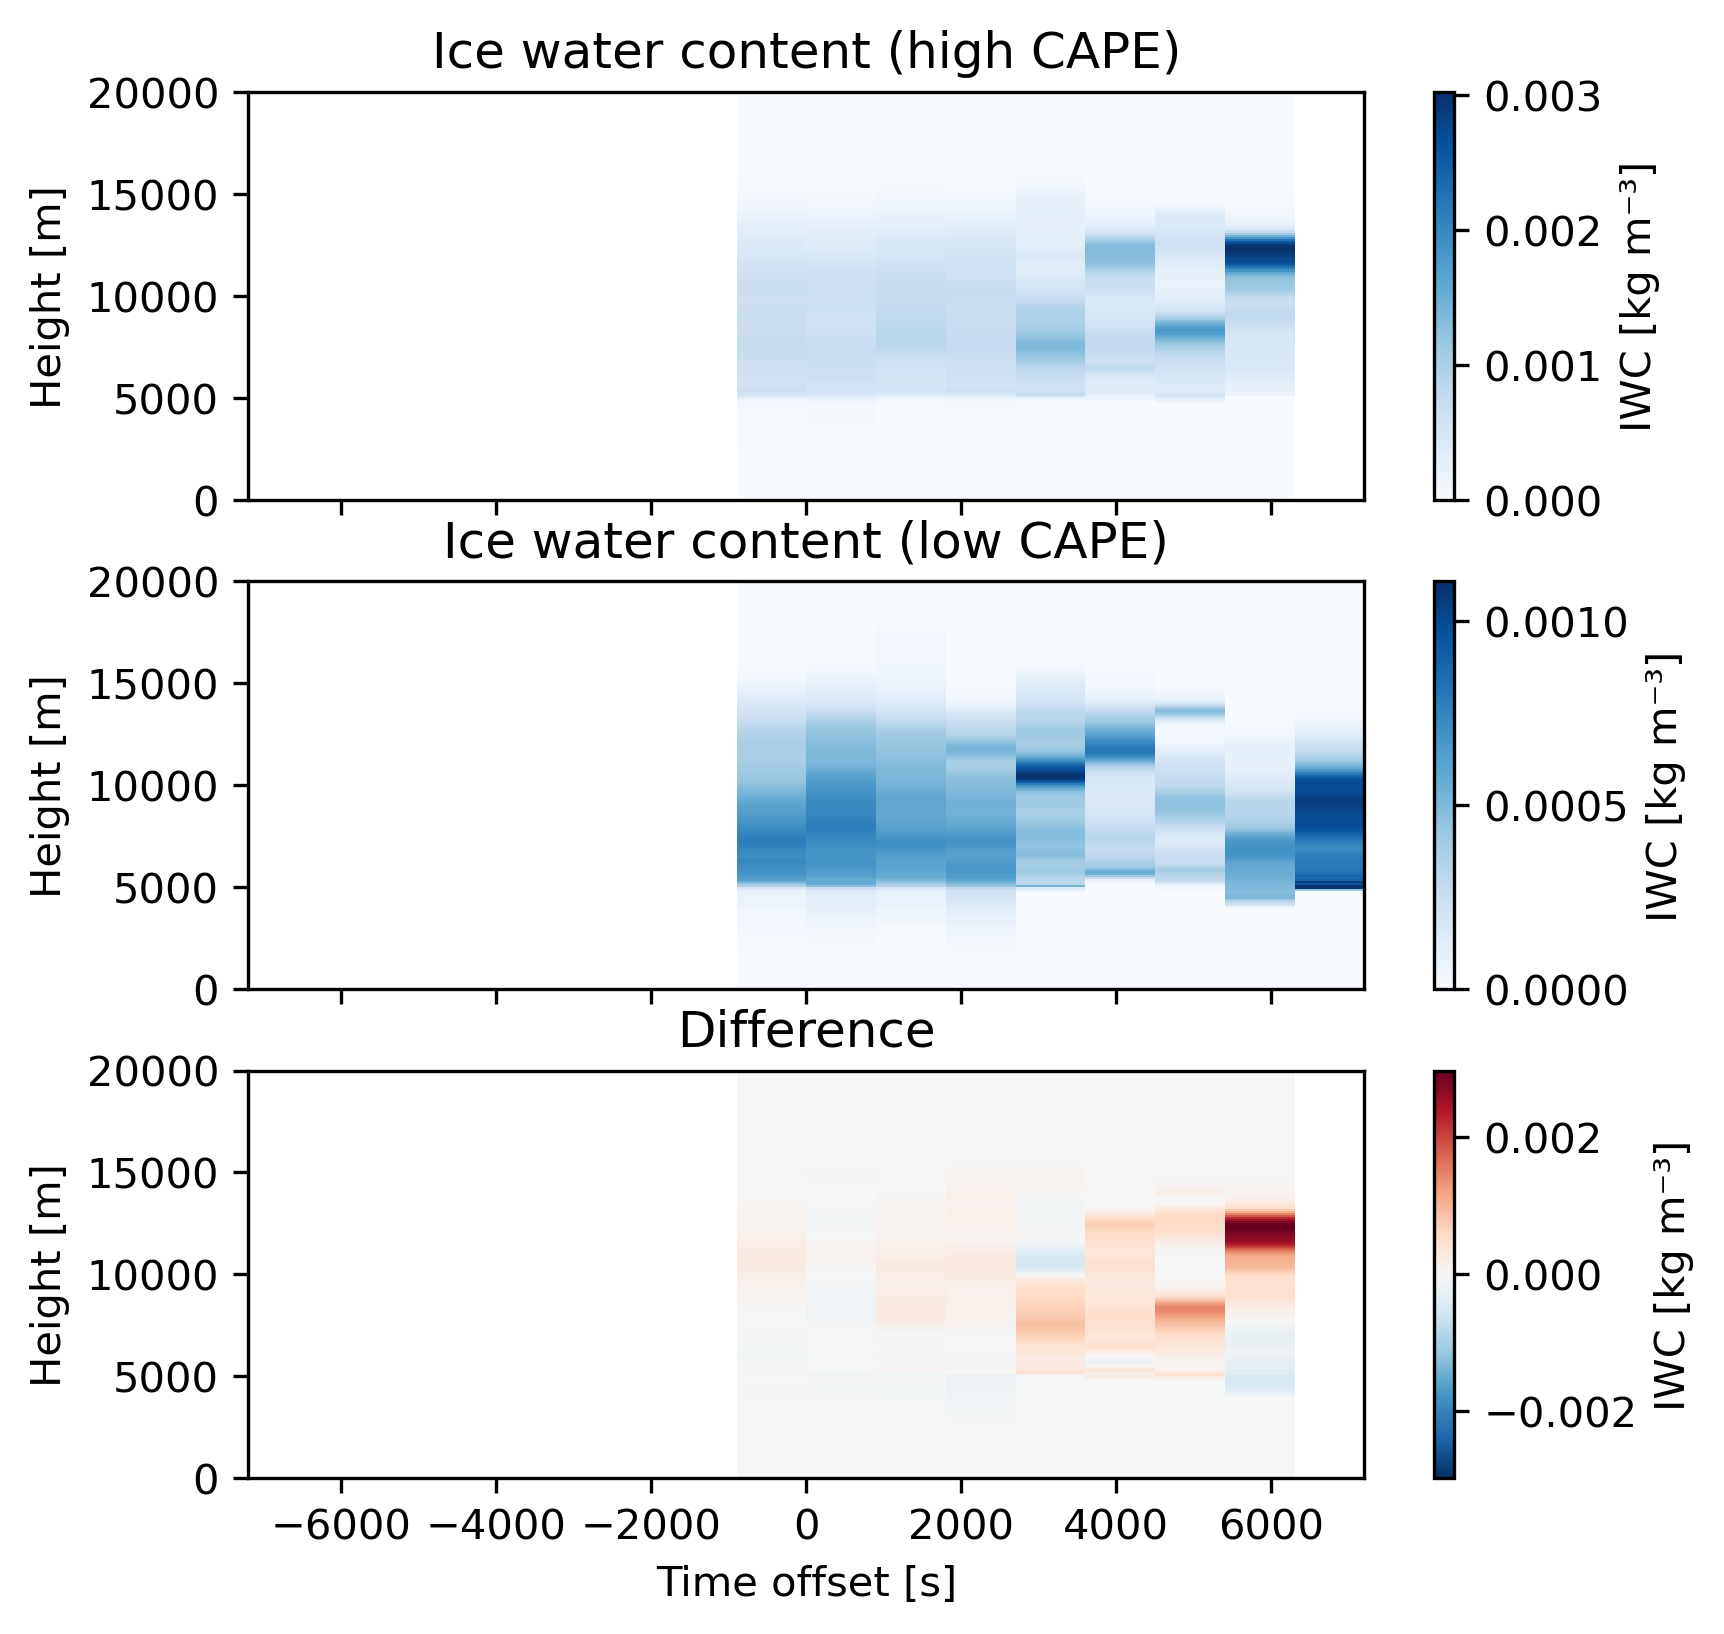

In [104]:
fig, axes = plt.subplots(3,1,dpi=300, sharex=True, figsize=(6,6))

acm_cap_comp_high.ice_water_content.T.plot(ax=axes[0], cbar_kwargs={"label":"IWC [kg m⁻³]"}, cmap="Blues")
acm_cap_comp_low.ice_water_content.T.plot(ax=axes[1], cbar_kwargs={"label":"IWC [kg m⁻³]"}, cmap="Blues")
(
    acm_cap_comp_high.ice_water_content
    -acm_cap_comp_low.ice_water_content
).T.plot(ax=axes[2], cbar_kwargs={"label":"IWC [kg m⁻³]"}, cmap="RdBu_r")
axes[0].set_xlabel("")
axes[1].set_xlabel("")
axes[2].set_xlabel("Time offset [s]")
axes[0].set_title("Ice water content (high CAPE)")
axes[1].set_title("Ice water content (low CAPE)")
axes[2].set_title("Difference")